# Cinemática de un robot SCARA

En este notebook se analizan los problemas de cinemática directa e inversa para un manipulador SCARA (Selective Compliance Arm for Robotic Assembly), un robot plano con dos articulaciones rotatorias en el plano xy, una articulación prismática en z y una articulación rotacional de orientación.

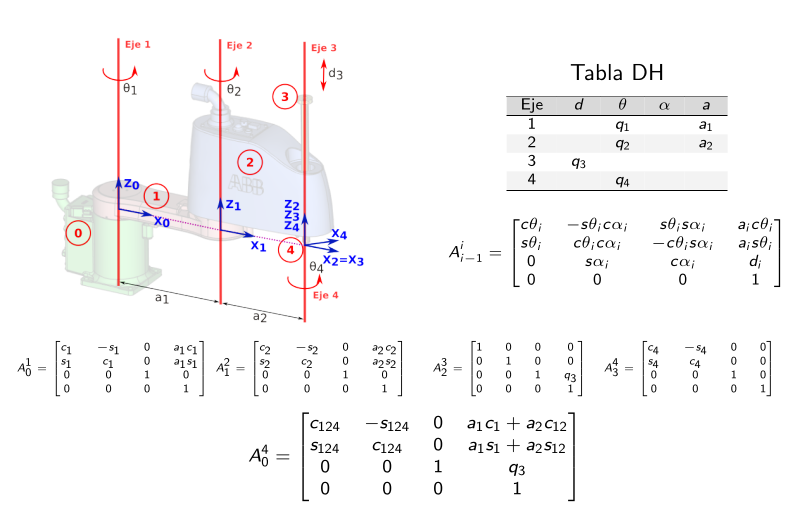

In [ ]:
import numpy as np

def fk_scara(q, a=[0.2,0.2]):
    """
    Cinemática directa de un SCARA.

    Parámetros
    ----------
    q : array-like (4,)
        Variables articulares [q1, q2, q3, q4]
    a : array-like (2,)
        Longitudes [a1, a2]

    Retorna
    -------
    POSE : ndarray (4,4)
        Matriz homogénea final
    conf : int
        Configuración (signo de q2)
    """

    q = np.asarray(q)
    a = np.asarray(a)

    q12 = q[0] + q[1]
    q124 = q12 + q[3]

    A10 = np.array([
        [np.cos(q[0]), -np.sin(q[0]), 0, a[0]*np.cos(q[0])],
        [np.sin(q[0]),  np.cos(q[0]), 0, a[0]*np.sin(q[0])],
        [0,             0,            1, 0],
        [0,             0,            0, 1]
    ])

    A21 = np.array([
        [np.cos(q[1]), -np.sin(q[1]), 0, a[1]*np.cos(q[1])],
        [np.sin(q[1]),  np.cos(q[1]), 0, a[1]*np.sin(q[1])],
        [0,             0,            1, 0],
        [0,             0,            0, 1]
    ])

    A32 = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, q[2]],
        [0, 0, 0, 1]
    ])

    A43 = np.array([
        [np.cos(q[3]), -np.sin(q[3]), 0, 0],
        [np.sin(q[3]),  np.cos(q[3]), 0, 0],
        [0,             0,            1, 0],
        [0,             0,            0, 1]
    ])

    # Producto homogéneo completo (producto matricial)
    POSE = A10 @ A21 @ A32 @ A43

    # Forma cerrada optimizada (más eficiente en este caso)
    #POSE = np.array([
    #    [np.cos(q124), -np.sin(q124), 0, a[0]*np.cos(q[0]) + a[1]*np.cos(q12)],
    #    [np.sin(q124),  np.cos(q124), 0, a[0]*np.sin(q[0]) + a[1]*np.sin(q12)],
    #    [0,             0,            1, q[2]],
    #    [0,             0,            0, 1]
    #])

    # Configuración del codo (necesaria para la IK)
    conf = np.sign(q[1])
    if conf == 0:
        conf = 1

    return POSE, int(conf)


In [ ]:
def ik_scara(POSE, conf, q1_ini=0, a=[0.2,0.2]):
    """
    Cinemática inversa de un SCARA.

    Parámetros
    ----------
    POSE : ndarray (4,4)
        Matriz homogénea objetivo
    conf : int
        Configuración (+1 o -1)
    q0_sing : double
        Valor del eje 1 en el caso de singularidad interna
    a : array-like (2,)
        Longitudes [a1, a2]

    Retorna
    -------
    q : ndarray (4,)
        Variables articulares [q1, q2, q3, q4]
    status : int
        0 = OK, -1 = no alcanzable
    """

    a = np.asarray(a)
    q = np.zeros(4)

    px = POSE[0, 3]
    py = POSE[1, 3]
    pz = POSE[2, 3]

    # Alcanzabilidad: distancia a la posición deseada vs radio máximo
    if (px**2 + py**2) > (a[0] + a[1])**2:
        print("El punto no es alcanzable")
        return q, -1

    # Ley de cosenos para q2: crítico identificar las dos soluciones
    c2 = (px**2 + py**2 - (a[0]**2 + a[1]**2)) / (2 * a[0] * a[1])

    # Protección numérica (evita errores en sqrt cuando c2 > 1 por flota)
    c2 = np.clip(c2, -1.0, 1.0)

    s2 = conf * np.sqrt(1 - c2**2)
    q[1] = np.arctan2(s2, c2)

    # Cálculo de q1: singularidad interna cuando el punto está en el origen
    denom = px**2 + py**2
    if np.linalg.norm(denom) < 1e-5:
        q[0] = q1_ini  # Singularidad: cualquier q1 alcanza el origen
    else:
        s1 = (a[1]*(py*c2 - px*s2) + a[0]*py) / denom
        c1 = (a[1]*(py*s2 + px*c2) + a[0]*px) / denom
        q[0] = np.arctan2(s1, c1)  # atan2 evita ambigüedad en cuadrantes

    # Articulación prismática: directa del setpoint z
    q[2] = pz

    # Orientación final: desacopla rotación del plano vs yaw
    q[3] = np.arctan2(POSE[1, 0], POSE[0, 0]) - q[0] - q[1]

    return q, 0


In [ ]:
# Prueba cinemática analítica: debe recuperar exactamente la configuración original
q = np.array([0.5, -0.7, 0.3, 0.8])

print("q original:")
print(q)

# Forward: obtener POSE deseada y detectar configuración del codo
POSE_d, conf = fk_scara(q)

print("\nPOSE:")
print(POSE_d)
print("\nConfiguración detectada:", conf)

# Inverse: recuperar q desde POSE
q_rec, status = ik_scara(POSE_d, conf)

print("\nq recuperado:")
print(q_rec)
print("\nStatus:", status)

# Verificación: FK(q_rec) debe coincidir con POSE_d
POSE_rec, _ = fk_scara(q_rec)

print("\nPOSE reconstruida:")
print(POSE_rec)

# Comparaciones
print("\n¿POSE ≈ POSE_rec?:", np.allclose(POSE_d, POSE_rec, atol=1e-6))
print("Error en q:", q - q_rec)


q original:
[ 0.5 -0.7  0.3  0.8]

POSE:
[[ 0.82533561 -0.56464247  0.          0.37152983]
 [ 0.56464247  0.82533561  0.          0.05615124]
 [ 0.          0.          1.          0.3       ]
 [ 0.          0.          0.          1.        ]]

Configuración detectada: -1

q recuperado:
[ 0.5 -0.7  0.3  0.8]

Status: 0

POSE reconstruido:
[[ 0.82533561 -0.56464247  0.          0.37152983]
 [ 0.56464247  0.82533561  0.          0.05615124]
 [ 0.          0.          1.          0.3       ]
 [ 0.          0.          0.          1.        ]]

¿POSE ≈ POSE_rec?: True
Error en q: [-1.11022302e-16  1.11022302e-16  0.00000000e+00 -1.11022302e-16]


## Cinemática inversa mediante optimización numérica

Cuando la solución analítica resulta compleja o no existe en forma cerrada, es posible recurrir a métodos numéricos basados en optimización. Se plantea un problema de minimización donde se busca encontrar las variables articulares $\mathbf{q}$ que minimicen el error entre la pose actual y la pose deseada.

In [ ]:
from scipy.optimize import minimize

def ik_scara_numerica(POSE_d, q0=None, a=[0.2,0.2], method='BFGS', verbose=False):
    """
    Cinemática inversa numérica para SCARA.

    Parámetros
    ----------
    POSE_d : ndarray (4,4)
        Pose deseada
    q0 : ndarray (4,), opcional
        Inicialización
    a : array-like (2,), opcional
        Parámetros del robot
    method : str
        Método de optimización
    verbose : bool
        Mostrar info del optimizador

    Retorna
    -------
    q_opt : ndarray (4,)
    res : OptimizeResult
    """

    if q0 is None:
        q0 = np.random.randn(4)

    def error_estimacion(q):
        """Función de costo: suma de errores cuadráticos.
        CRÍTICO: Escalas diferentes (m vs radianes) → solución subóptima."""
        POSE, _ = fk_scara(q, a)

        # Error en posición (m)
        e_pos = POSE[:3, 3] - POSE_d[:3, 3]

        # Error en orientación (rad) → desbalance en la función de costo
        theta = np.arctan2(POSE[1,0], POSE[0,0])
        theta_d = np.arctan2(POSE_d[1,0], POSE_d[0,0])
        e_ori = theta - theta_d

        return np.dot(e_pos, e_pos) + e_ori**2

    res = minimize(
        error_estimacion,
        q0,
        method=method,
        options={'disp': verbose}
    )

    return res.x, res


In [39]:
q_opt, res = ik_scara_numerica(POSE_d, verbose=True)
POSE_final, _ = fk_scara(q_opt)

print("\nq deseado:", q)
print("\nq óptimo:", q_opt)

print("\nPOSE deseada:")
print(POSE_d)

print("\nPOSE alcanzada:")
print(POSE_final)

print("\nError final:", res.fun)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 12
         Function evaluations: 80
         Gradient evaluations: 16

q deseado: [ 0.5 -0.7  0.3  0.8]

q óptimo: [-0.20003699  0.70015212  0.29999985  0.09988206]

POSE deseada:
[[ 0.82533561 -0.56464247  0.          0.37152983]
 [ 0.56464247  0.82533561  0.          0.05615124]
 [ 0.          0.          1.          0.3       ]
 [ 0.          0.          0.          1.        ]]

POSE alcanzada:
[[ 0.8253372  -0.56464015  0.          0.37151732]
 [ 0.56464015  0.8253372   0.          0.0561642 ]
 [ 0.          0.          1.          0.29999985]
 [ 0.          0.          0.          1.        ]]

Error final: 3.322647408462891e-10


In [ ]:
# Análisis de convergencia: 500 intentos de IK numérica desde inicializaciones random
N = 500
tol_pose = 1e-4  # Tolerancia de pose (m)
tol_q = 1e-3     # Tolerancia de variables articulares (rad)

exitos = 0
fallos = 0

err = np.zeros(N)
err_q = np.zeros(N)

for i in range(N):
    # Genero q aleatorio en [-pi, pi]
    q_d = np.random.randn(4)
    q_d = (q_d + np.pi) % (2*np.pi) - np.pi

    # FK: obtengo la POSE "verdadera"
    POSE_d, _ = fk_scara(q_d)

    # IK numérica: inicializo desde otro punto random (no desde q_d)
    q_opt, res = ik_scara_numerica(POSE_d)
    q_opt = (q_opt + np.pi) % (2*np.pi) - np.pi

    # Evaluación: recuperé el mismo q_d o uno equivalente?
    POSE_rec, _ = fk_scara(q_opt)

    # Dos métricas: error en pose vs error en variables articulares
    err[i] = np.linalg.norm(POSE_d - POSE_rec)    # ¿Llego a la misma POSE?
    err_q[i] = np.linalg.norm(q_d - q_opt)        # ¿Recuperé el mismo q?

# Estadísticas
exitos = np.sum(err_q <= tol_q)
fallos = np.sum(err_q > tol_q)

print("Total de experiencias:", N)
print("Éxitos en recuperar q_d:", exitos)
print("Fallos en recuperar q_d:", fallos)
print("Tasa de éxito:", exitos / N)

print("\nExitos en recrear la pose deseada:", np.sum(err <= tol_pose))
print("Fallos en recrear la pose deseada:", np.sum(err > tol_pose))


Total de experiencias: 500
Éxitos en recuperar q_d: 257
Fallos en recuperar q_d: 243
Tasa de éxito: 0.514

Exitos en recrear la pose deseada: 476
Fallos en recrear la pose deseada: 24


### Resultados y observaciones críticas

A partir del experimento realizado con 500 intentos de cinemática inversa numérica se observan dos fenómenos importantes:

1. **Recuperación de variables articulares**: Aproximadamente el 50% de los casos **no recupera** el valor original de $\mathbf{q}_d$, a pesar de haber convergido numéricamente.
¿Cuál es la causa de este problema?

2. **Recuperación de la pose**: Sin embargo, en la **mayoría de los casos** se obtiene una solución $\mathbf{q}$ que permite llegar a la pose deseada con el margen de tolerancia especificado.

En este caso la cinemática inversa numérica falla en recuperar perfectamente $\text{POSE}_d$ porque el problema está mal planteado en la función de costo. El error se define como una ponderación igualitaria entre el error de posición (en metros) y el error de orientación (en radianes), que tienen escalas completamente diferentes. Esto hace que el optimizador privilegie indebidamente uno u otro término, dependiendo de la magnitud relativa de los errores.

## Cinemática usando Robotics Toolbox

La librería **Robotics Toolbox** de Peter Corke proporciona herramientas profesionales para modelado cinemático y dinámico de robots. A continuación se implementa el mismo robot SCARA utilizando esta librería y se comparan los resultados obtenidos con los métodos anteriores.

In [ ]:
import roboticstoolbox as rtb

# Modelo SCARA mediante parámetros Denavit-Hartenberg
scara = rtb.DHRobot([
    rtb.RevoluteDH(a=0.2, qlim=[-np.pi, np.pi]),        # q1: rotación plana
    rtb.RevoluteDH(a=0.2, qlim=[-np.pi, np.pi]),        # q2: rotación plana
    rtb.PrismaticDH(qlim=[0.0, 0.5]),                   # q3: desplazamiento vertical 
    rtb.RevoluteDH(qlim=[-np.pi, np.pi])                # q4: orientación final
])

print(scara)


DHRobot: , 4 joints (RRPR), dynamics, standard DH parameters
┌──────┬─────┬─────┬──────┬─────────┬────────┐
│  θⱼ  │ dⱼ  │ aⱼ  │  ⍺ⱼ  │   q⁻    │   q⁺   │
├──────┼─────┼─────┼──────┼─────────┼────────┤
│  q1  │   0 │ 0.2 │ 0.0° │ -180.0° │ 180.0° │
│  q2  │   0 │ 0.2 │ 0.0° │ -180.0° │ 180.0° │
│ 0.0° │  q3 │   0 │ 0.0° │     0.0 │    0.5 │
│  q4  │   0 │   0 │ 0.0° │ -180.0° │ 180.0° │
└──────┴─────┴─────┴──────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



In [80]:
# Comparativa con Robotics Toolbox: usamos ikine_LM (Levenberg-Marquardt)
q = np.r_[0.5, -0.7, 0.3, 0.8]

print("q original:")
print(q)

# Cinemática directa
POSE_d = scara.fkine(q)

print("\nPOSE:")
print(POSE_d)

# IK: RTB usa método Levenberg-Marquardt (más robusto que BFGS)
sol = scara.ikine_LM(POSE_d)
q_rec = sol.q

print("\nq recuperado (RTB IK):")
print(q_rec)
print("\nSuccess:", sol.success)

# Verificación: FK(q_rec) vs POSE_d
POSE_rec = scara.fkine(q_rec)

print("\nPOSE reconstruida:")
print(POSE_rec)

# Comparaciones: tolerancia más relajada por redondeos de RTB
print("\n¿POSE ≈ POSE_rec?:", np.allclose(POSE_d.A, POSE_rec.A, atol=1e-5))
print("Error en q:", q - q_rec)


q original:
[ 0.5 -0.7  0.3  0.8]

POSE:
   0.8253   -0.5646    0         0.3715    
   0.5646    0.8253    0         0.05615   
   0         0         1         0.3       
   0         0         0         1         


q recuperado (RTB IK):
[-0.20004292  0.70008592  0.3         0.099957  ]

Success: True

POSE reconstruida:
   0.8253   -0.5646    0         0.3715    
   0.5646    0.8253    0         0.05615   
   0         0         1         0.3       
   0         0         0         1         


¿POSE ≈ POSE_rec?: True
Error en q: [ 7.00042924e-01 -1.40008592e+00  1.66533454e-16  7.00043000e-01]
